In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
%matplotlib inline

In [5]:
df=pd.read_csv('Cleaned_trend_bit.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5241 entries, 0 to 5240
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Diff    5241 non-null   float64
 1   Time1   5241 non-null   float64
 2   Start   5241 non-null   object 
 3   End     5241 non-null   object 
 4   Time2   5241 non-null   float64
 5   target  5241 non-null   int64  
dtypes: float64(3), int64(1), object(2)
memory usage: 286.6+ KB


In [6]:
df['target']=pd.DataFrame(np.where(df['Time2']>60,1,0))
df['target'].value_counts()

target
0    2649
1    2592
Name: count, dtype: int64

In [7]:
df['momentum']=abs(df['Diff']/df['Time1'])
df['accl']=df['momentum']/df['Time1']
df.head()

,Diff,Time1,Start,End,Time2,target,momentum,accl
0,-16.968750,60.0,2026-06-26 05:30:00+05:30,2026-06-26 05:31:00+05:30,60.0,0,0.282813,0.004714
1,82.468750,60.0,2026-06-26 05:31:00+05:30,2026-06-26 05:32:00+05:30,120.0,1,1.374479,0.022908
2,-36.699219,120.0,2026-06-26 05:32:00+05:30,2026-06-26 05:34:00+05:30,60.0,0,0.305827,0.002549
3,42.820312,60.0,2026-06-26 05:34:00+05:30,2026-06-26 05:35:00+05:30,180.0,1,0.713672,0.011895
4,-65.839844,180.0,2026-06-26 05:35:00+05:30,2026-06-26 05:38:00+05:30,60.0,0,0.365777,0.002032


In [8]:
weights = np.where((df['Diff'] >= -750) & (df['Diff'] <= 750) & (df['momentum'] > 3.0), 1, 0)
df['alpha_zone']=pd.DataFrame(weights)
df.head()

,Diff,Time1,Start,End,Time2,target,momentum,accl,alpha_zone
0,-16.968750,60.0,2026-06-26 05:30:00+05:30,2026-06-26 05:31:00+05:30,60.0,0,0.282813,0.004714,0
1,82.468750,60.0,2026-06-26 05:31:00+05:30,2026-06-26 05:32:00+05:30,120.0,1,1.374479,0.022908,0
2,-36.699219,120.0,2026-06-26 05:32:00+05:30,2026-06-26 05:34:00+05:30,60.0,0,0.305827,0.002549,0
3,42.820312,60.0,2026-06-26 05:34:00+05:30,2026-06-26 05:35:00+05:30,180.0,1,0.713672,0.011895,0
4,-65.839844,180.0,2026-06-26 05:35:00+05:30,2026-06-26 05:38:00+05:30,60.0,0,0.365777,0.002032,0


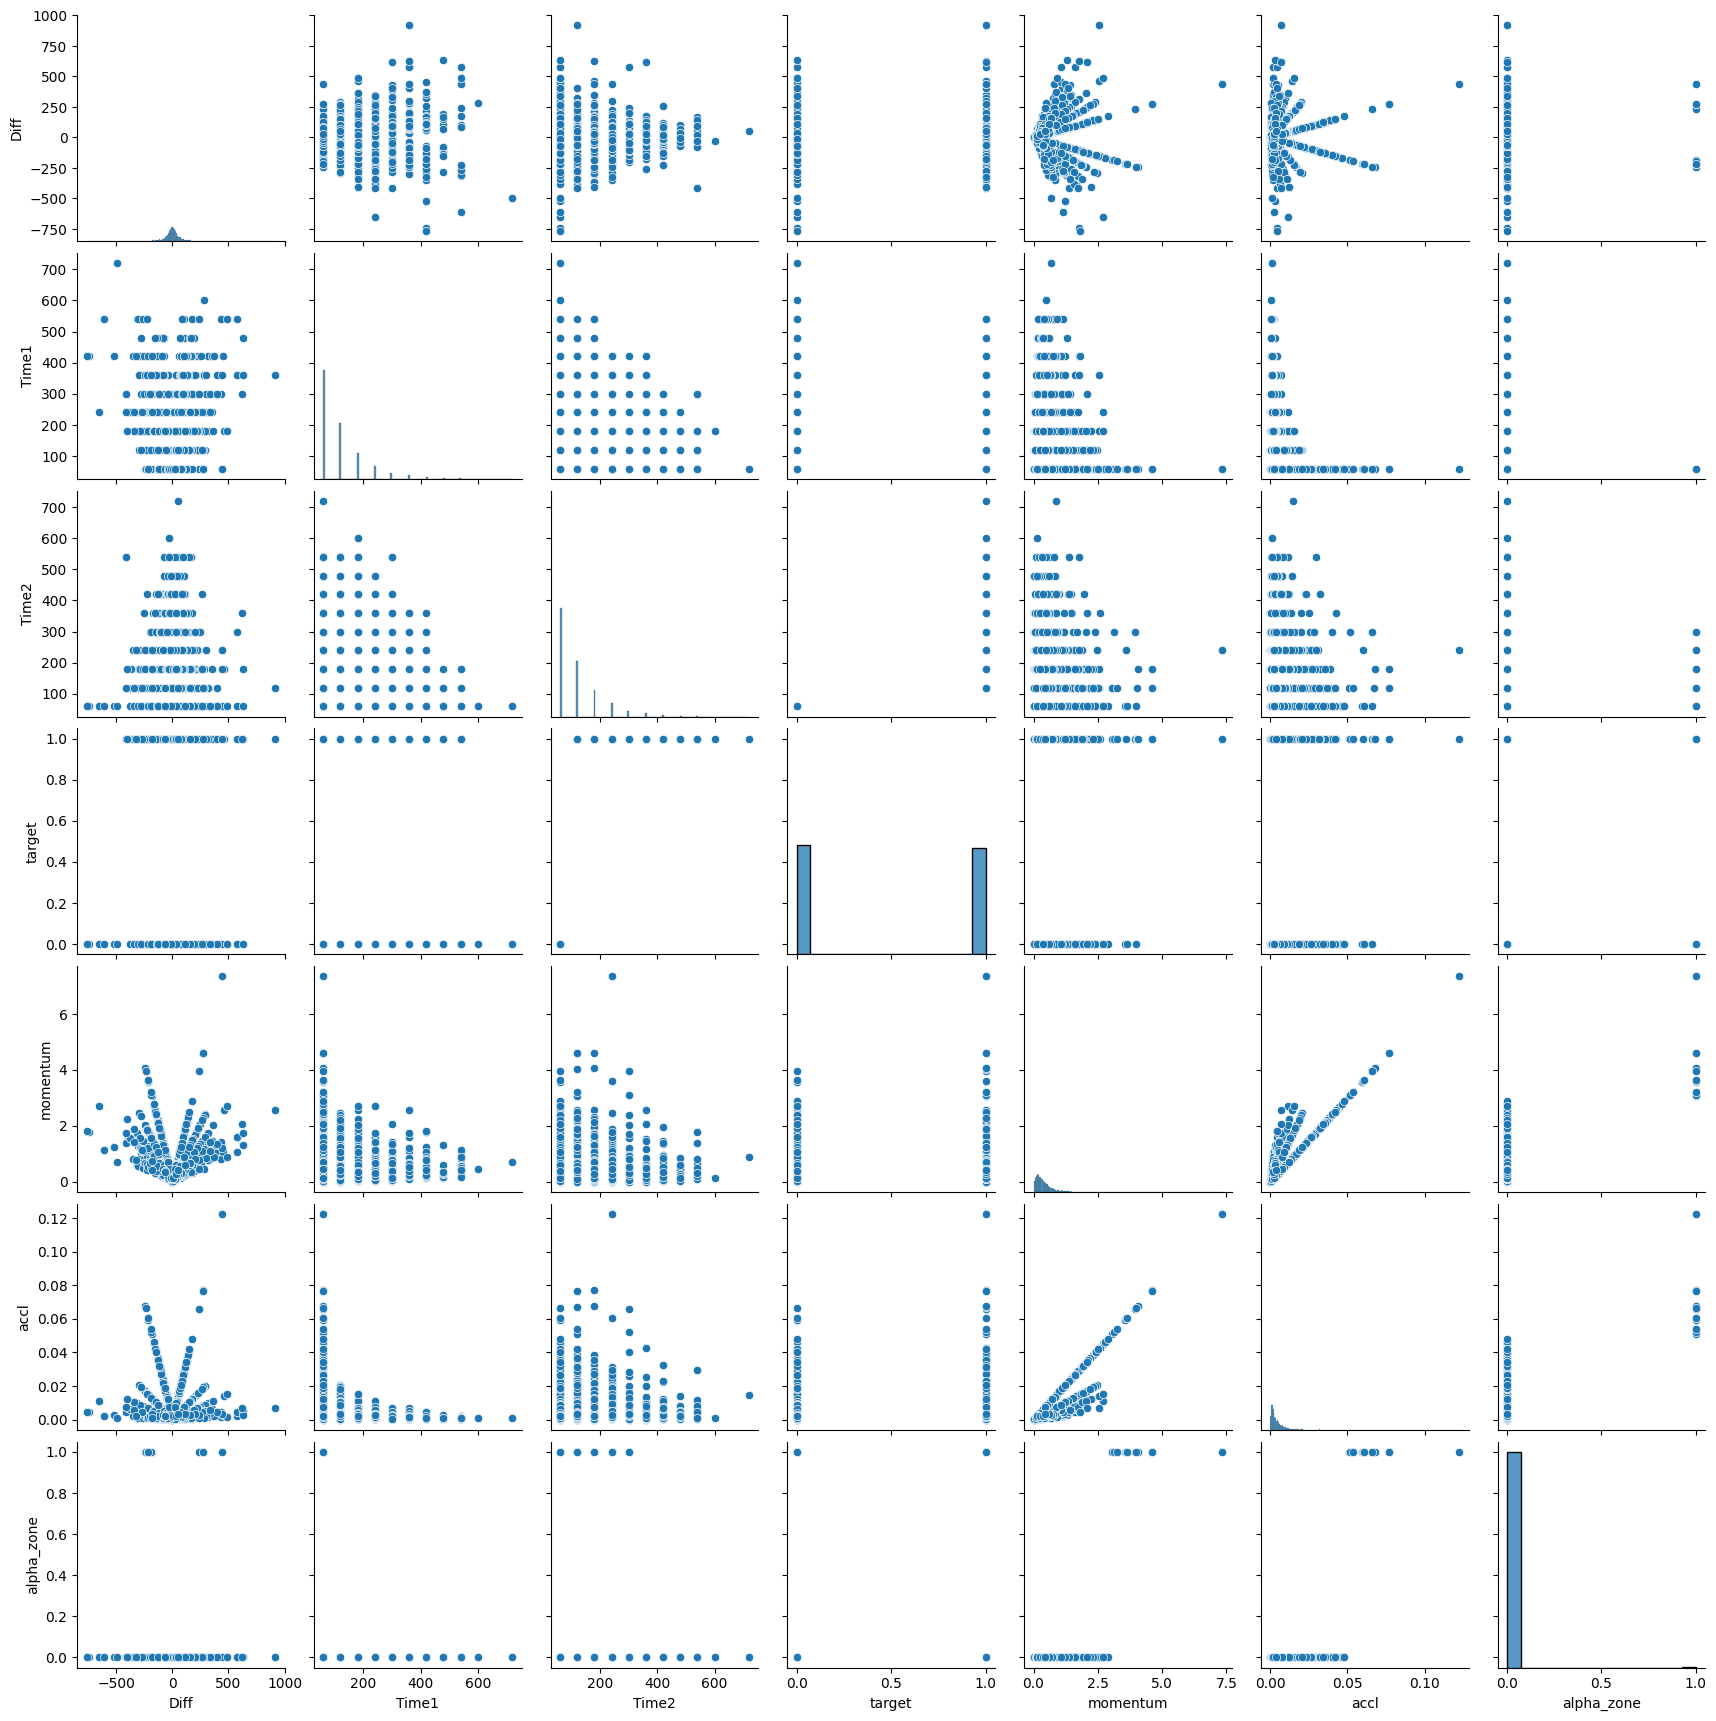

In [6]:
sns.pairplot(df)

<Axes: xlabel='Time2', ylabel='alpha_zone'>

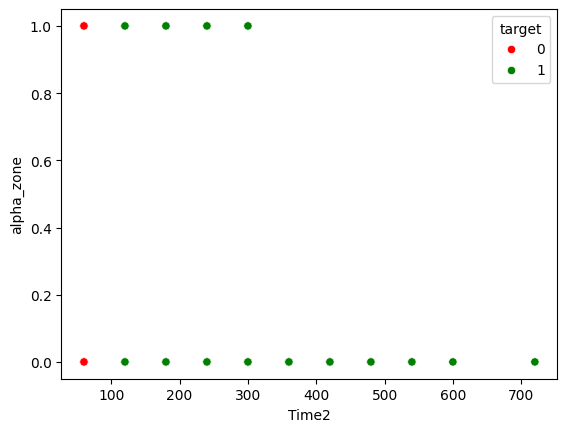

In [7]:
sns.scatterplot(df,x='Time2',y='alpha_zone',hue=df['target'],palette={0:'red',1:'green'})

In [8]:
low_diff_min = -750
low_diff_max = 750
high_momentum_threshold = 3 

# 2. Create a strict bounding box to filter your DataFrame
theory_zone = df[(df['Diff'] >= low_diff_min) & 
                 (df['Diff'] <= low_diff_max) & 
                 (df['momentum'] >= high_momentum_threshold)]

# 3. Calculate the Win Rate in this specific zone
total_trades = len(theory_zone)
wins = len(theory_zone[theory_zone['target'] == 1]) # Green dots
losses = total_trades - wins # Red dots

In [9]:
print(total_trades,wins,losses)

13 10 3


<Axes: xlabel='momentum', ylabel='Count'>

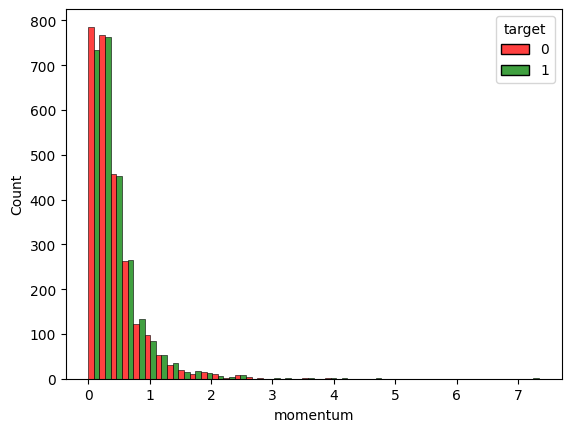

In [10]:
sns.histplot(df,bins=40,x='momentum',hue='target',palette={0:'red',1:'green'},multiple='dodge')

## Trying Decision Tree

In [9]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,precision_score,classification_report,accuracy_score

In [10]:
x=df[['Time1','momentum','accl']]
y=df['target']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,stratify=y,random_state=70)

In [11]:
tree1=DecisionTreeClassifier()
tree1.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [12]:
y_pred=tree1.predict(x_test)

In [13]:
print(confusion_matrix(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[282 248]
 [268 251]]
0.503006012024048
0.5081029551954243


## Trying Random Forest

In [14]:
# w=((x_train['alpha_zone'].to_numpy())*99)+1

In [16]:
from sklearn.ensemble import RandomForestClassifier
forest1=RandomForestClassifier(max_depth= 10,min_samples_leaf=40,min_samples_split=50,  n_estimators= 100)
forest1.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,50
,min_samples_leaf,40
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
# y_pred1=forest1.predict(x_test)
y_pred1=forest1.predict(x_test)
y_pred1

array([1, 0, 0, ..., 1, 1, 0], shape=(1049,))

In [18]:
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))
print(accuracy_score(y_test,y_pred1))

[[276 254]
 [273 246]]
0.492
0.49761677788369874


## SVM Classifier

In [20]:
from sklearn.svm import SVC
svc=SVC()
svc.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [21]:
y_pred2=svc.predict(x_test)

In [22]:
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))
print(accuracy_score(y_test,y_pred2))

[[305 225]
 [307 212]]
0.4851258581235698
0.49285033365109626


## Trying KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [20]:
knn=KNeighborsClassifier(algorithm='ball_tree',leaf_size= 30, n_neighbors= 2, weights= 'distance')
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [21]:
knn.fit(x_train_scaled,y_train)

,n_neighbors,2
,weights,'distance'
,algorithm,'ball_tree'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [22]:
y_pred3=knn.predict(x_test_scaled)
knn.n_neighbors

2

In [24]:
print(confusion_matrix(y_test,y_pred3))
print(f'Precision:{precision_score(y_test,y_pred3)}')
print(f'Accuracy:{accuracy_score(y_test,y_pred3)}')

[[288 242]
 [271 248]]
Precision:0.5061224489795918
Accuracy:0.5109628217349858


## Trying Gradient boost

In [28]:
from sklearn.ensemble import GradientBoostingClassifier
gboost=GradientBoostingClassifier()
gboost.fit(x_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [29]:
y_pred4=gboost.predict(x_test)

In [30]:
print(confusion_matrix(y_test,y_pred4))
print(precision_score(y_test,y_pred4))
print(accuracy_score(y_test,y_pred4))

[[223 307]
 [214 305]]
0.49836601307189543
0.5033365109628217


## GridSearch CV

In [31]:
from sklearn.model_selection import GridSearchCV,StratifiedKFold
models=[
    (tree1,{'max_depth':[3,4,5,6,7,8,9,10,20,40,50],'min_samples_split':[2,4,5,10,20,40,60,80,100],'min_samples_leaf':[1,2,3,4,5,10,10,20,30,40,50]}),
(forest1,{'n_estimators':[50,60,100,200,250,150],'max_depth':[3,4,5,6,7,8,9,10,20,40,50],
            'min_samples_split':[2,4,5,10,20,40,60,80,100],
            'min_samples_leaf':[1,2,3,4,5,10,10,20,30,40,50]}),
(knn,{'n_neighbors':[2,3,5,6,7,10,15,17,20],'weights':['uniform','distance'],'algorithm':['ball_tree','kd_tree','brute'],'leaf_size':[2,3,5,10,15,20,25,30,35,40,45,50]}),
]
cv=StratifiedKFold(5)

In [ ]:
for model,params in models:
    grid=GridSearchCV(estimator=model,param_grid=params,cv=cv,n_jobs=-1,scoring='accuracy')
    if model == knn:
        grid.fit(x_train_scaled,y_train)
        y_p=grid.predict(x_test_scaled)
    else:
        grid.fit(x_train,y_train)
        y_p=grid.predict(x_test)
    print(f'{model}:\n{confusion_matrix(y_test,y_p)}\nAccuracy:{accuracy_score(y_test,y_p)}\nPrecision{precision_score(y_test,y_p)}\n{grid.best_params_}')
    print('-------------------------------')


DecisionTreeClassifier():
[[301 229]
 [296 223]]
Accuracy:0.49952335557673977
Precision0.49336283185840707
{'max_depth': 40, 'min_samples_leaf': 40, 'min_samples_split': 100}
-------------------------------


## FINALIZING KNN

In [ ]:
# import pickle
# pickle.dump(knn,open('dt.pkl','wb'))
# # pickle.dump(scaler,open('scaler.pkl','wb'))

In [32]:
unseen=pd.read_csv('Unseen_data.csv')
x_us=unseen[['Time1','momentum','accl']]
y_us=unseen['target']
x_us

,Time1,momentum,accl
0,120.0,0.473242,0.003944
1,60.0,0.347656,0.005794
2,60.0,0.007031,0.000117
3,240.0,0.170052,0.000709
4,60.0,1.190169,0.019836
...,...,...,...
342,60.0,0.250326,0.004172
343,240.0,0.408952,0.001704
344,60.0,0.202669,0.003378
345,60.0,0.102995,0.001717


In [33]:
# knn=KNeighborsClassifier(algorithm='ball_tree',leaf_size= 30, n_neighbors= 2, weights= 'distance')
# scaler=StandardScaler()
x_us_scaled=scaler.transform(x_us)

In [ ]:
# knn.fit(x_us_scaled,y_us)

,n_neighbors,2
,weights,'distance'
,algorithm,'ball_tree'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [34]:
y_p=knn.predict(x_us_scaled)

In [35]:
print(confusion_matrix(y_us,y_p))
print(precision_score(y_us,y_p))
print(accuracy_score(y_us,y_p))

[[105  63]
 [ 72 107]]
0.6294117647058823
0.6109510086455331


In [15]:
from datetime import datetime
datetime.isoformat(datetime.now())

'2026-07-17T14:16:01.995343'